# The Bernstein–Vazirani Algorithm

Bernstein–Vazirani is one of the cleanest demonstrations of quantum speed-up:

> **Problem.** A black-box function `f(x) = s · x mod 2` hides a secret bitstring `s ∈ {0, 1}^n`. Find `s`.
>
> **Classical cost:** `n` oracle queries (one per bit).
> **Quantum cost:** **1 oracle query.** Always.

The trick is *phase kick-back*: by putting the answer qubit in `|−⟩` we turn the oracle's bit-flips into phase shifts on the input qubits, and a final layer of Hadamards turns those phases into the answer.

> **What changed since the original notebook?** Only the standard Qiskit-1.0 / 2.x updates: explicit imports, `AerSimulator` from `qiskit_aer`, and `transpile` + `run` instead of `execute`. The pedagogy of the algorithm is unchanged.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

%matplotlib inline

### The "secret" we want to find

Bernstein–Vazirani is given a black-box oracle that computes `f(x) = s · x mod 2` for some hidden bitstring `s`. Our job is to discover `s`. Below is the secret we'll hide in the oracle – feel free to change it and re-run the notebook!

In [2]:
secretNumber = '110001110101'

### Allocating the qubits

We need:

- **`n` input qubits** – one for each bit of the secret (here `n = 12`).
- **1 ancilla qubit** – the qubit the oracle XOR-s its result into.
- **`n` classical bits** – to store the measurement of the input qubits.

Hence `QuantumCircuit(n + 1, n)`.

In [3]:
circuit = QuantumCircuit(len(secretNumber) + 1,len(secretNumber))

## Building the circuit

The recipe is:

1. **Hadamard** every input qubit so they are in equal superposition of all `2^n` strings.
2. Put the **ancilla** (last qubit) into `|−⟩` with `X` then `H`. This is the trick that turns the oracle's bit-flip into a **phase-kick**.
3. Apply the **oracle** `U_f`. We don't know `s` ourselves – the oracle does. Implement `f(x) = s · x mod 2` by placing a `CX` from input qubit `i` to the ancilla **iff** the `i`-th bit of `s` is 1.
4. Apply Hadamards on the input qubits again. The interference of phases collapses everything to exactly the bitstring `s`.
5. **Measure** the input qubits.

> Note: Qiskit numbers bits little-endian, so we iterate over `reversed(secretNumber)` to map bit `i` to qubit `i`.

In [4]:
circuit.h(range(len(secretNumber)))
circuit.x(len(secretNumber))
circuit.h(len(secretNumber))

circuit.barrier()

for index, one in enumerate(reversed(secretNumber)):
    print(f"index {index} is {one}")
    if one == "1":
        circuit.cx(index, len(secretNumber))

circuit.barrier()

circuit.h(range(len(secretNumber)))

circuit.barrier()

circuit.measure(range(len(secretNumber)),range(len(secretNumber)))

index 0 is 1
index 1 is 0
index 2 is 1
index 3 is 0
index 4 is 1
index 5 is 1
index 6 is 1
index 7 is 0
index 8 is 0
index 9 is 0
index 10 is 1
index 11 is 1


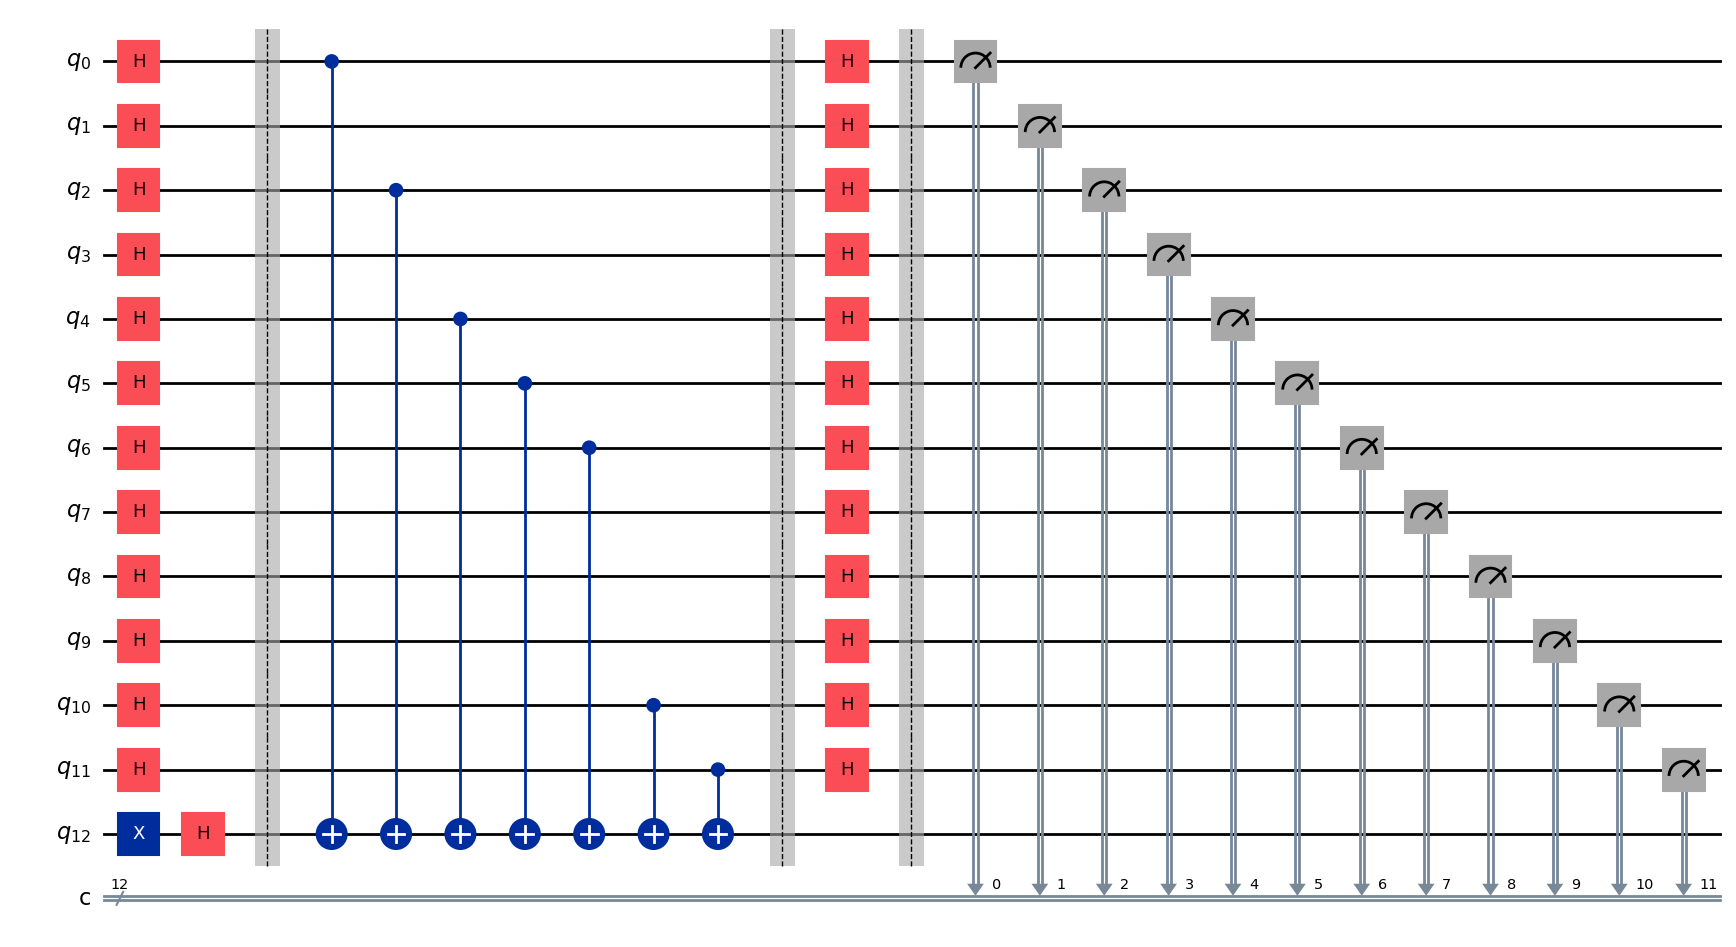

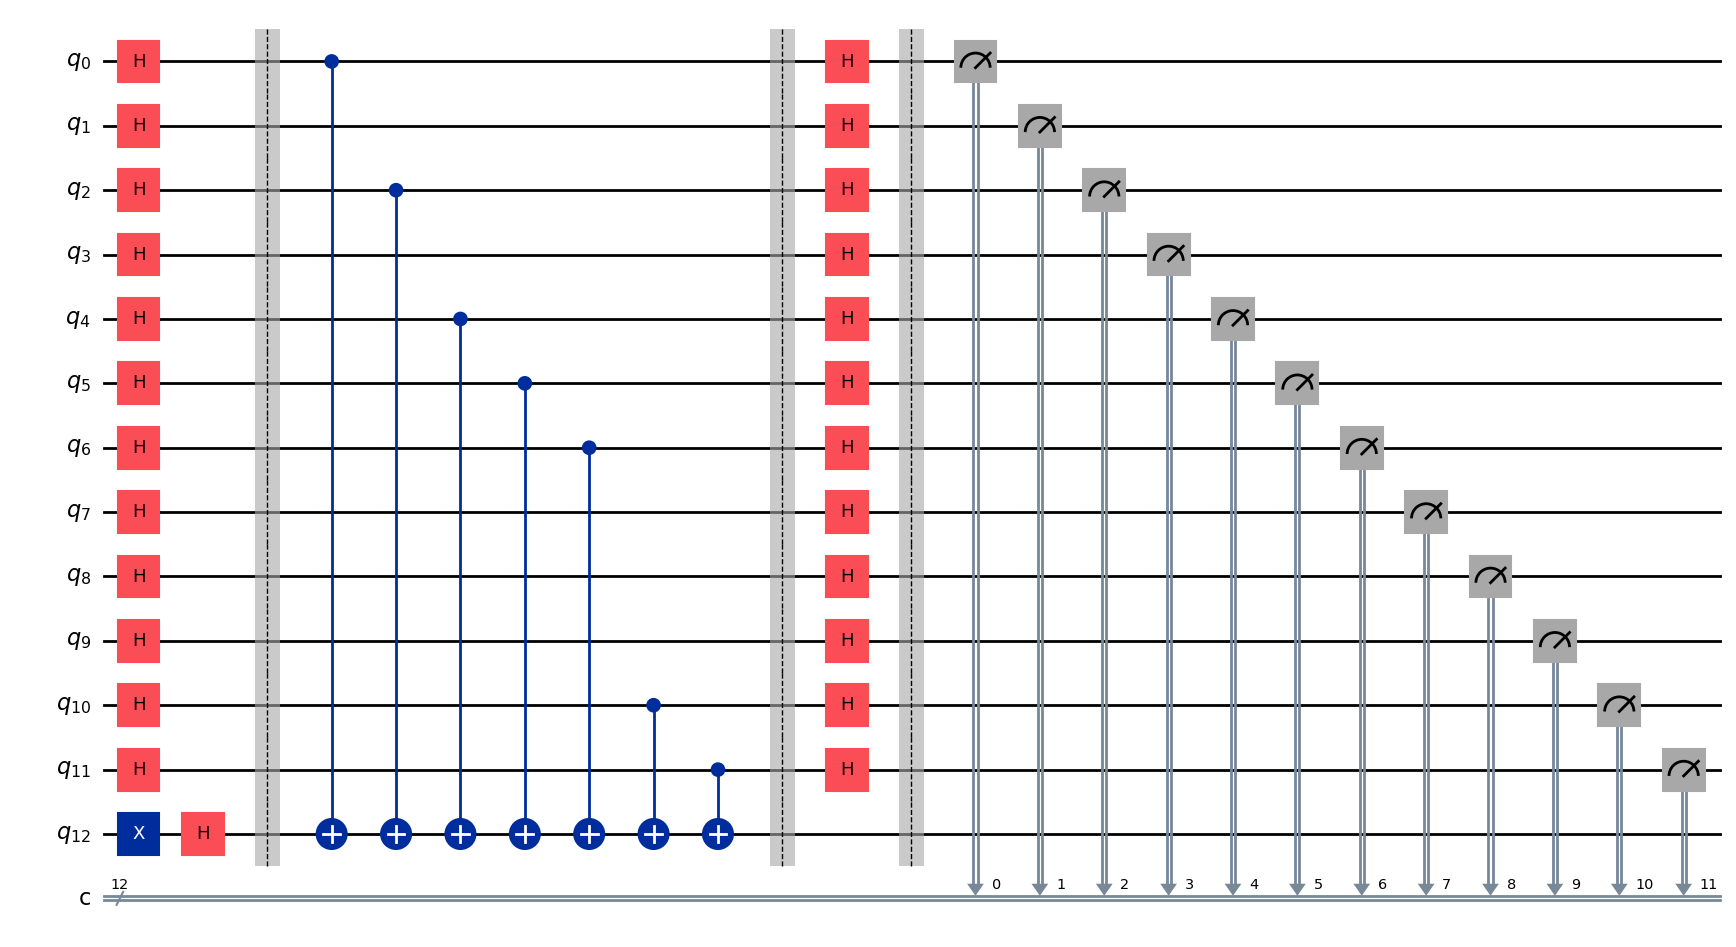

In [5]:
circuit.draw(output='mpl')

## Run – just **one shot** is enough!

A classical algorithm needs `n` queries to learn an `n`-bit secret. Bernstein–Vazirani learns it in **a single query**. We therefore set `shots=1`: the only outcome we ever see *is* the secret string.

In [6]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1).result()
counts = result.get_counts()
print(counts)

{'110001110101': 1}


In [7]:
#secretNumber = '110001110101'